3.1_:3

In [31]:
import sys
import platform

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import sys
print(sys.executable)

E:\ДушитьУдава\ML-P-\.venv\Scripts\python.exe


In [33]:
try:
    import sklearn
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

In [34]:
print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)

Python: 3.14.3
Executable: E:\ДушитьУдава\ML-P-\.venv\Scripts\python.exe
OS: Windows-11-10.0.26200-SP0
NumPy: 2.4.3
Pandas: 3.0.1
scikit-learn: 1.8.0


In [35]:
np.random.seed(42)

In [36]:
X = np.random.randn(100, 5)

In [37]:
print("Shape:", X.shape)
print("Dtype:", X.dtype)

Shape: (100, 5)
Dtype: float64


In [38]:
print("First 5 rows:")
print(X[:5])

First 5 rows:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
 [-0.23413696  1.57921282  0.76743473 -0.46947439  0.54256004]
 [-0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783]
 [-0.56228753 -1.01283112  0.31424733 -0.90802408 -1.4123037 ]
 [ 1.46564877 -0.2257763   0.0675282  -1.42474819 -0.54438272]]


3.1_:3

In [39]:
overall_mean = X.mean()
overall_std = X.std()

In [40]:
col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

In [41]:
print("Overall mean:", overall_mean)
print("Overall std:", overall_std)
print("\nPer-column mean:", col_mean)
print("Per-column std:", col_std)
print("Per-column min:", col_min)
print("Per-column max:", col_max)

Overall mean: 0.006837994588647575
Overall std: 0.9802715029966268

Per-column mean: [-0.04474719  0.07695423 -0.09387351  0.12805847 -0.03220203]
Per-column std: [0.89583921 0.9791772  0.97901142 0.95474576 1.06742857]
Per-column min: [-1.9520878  -2.30192116 -3.24126734 -1.91328024 -2.6197451 ]
Per-column max: [2.31465857 1.8861859  2.1221562  3.07888081 3.85273149]


4.1_:3

In [42]:
w = np.random.randn(5,)

In [43]:
y = X @ w

In [44]:
print("y.shape:", y.shape)
print("First values:", y[:5])

y.shape: (100,)
First values: [ 0.29997426  1.10790121 -1.61169274 -2.48647552  0.38401638]


4.2_:3

In [45]:
# TODO: веса и линейная комбинация
w = np.random.randn(5)
y = X @ w

print("w:", w)
print("y.shape:", y.shape)
print("y[:5]:", y[:5])

w: [-0.48712538 -0.59239392 -0.86399077  0.04852163 -0.83095012]
y.shape: (100,)
y[:5]: [-0.4511824  -1.95813854  1.63307003  1.73188785 -0.25532617]


In [46]:
# TODO: "истинные" веса, шум, y_true
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0])
noise = 0.1 * np.random.randn(X.shape[0])
y_true = X @ w_true + noise

# TODO: "предсказанные" веса и y_pred (можете взять w_true + небольшой шум)
w_guess = w_true + 0.5 * np.random.randn(5)
y_pred = X @ w_guess

# Метрики
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

# TODO (bonus): R2
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("MSE:", mse) #разница между значением и предсказанием в квадрате
print("MAE:", mae) #среднее модулей ошибок
print("RMSE:", rmse) #MSE под корнем
print("R2:", r2) #чем ближе к единице тем полезнее модель(точнее предсказания)
#очень хорошая модель

MSE: 2.0810210875860093
MAE: 1.121350145066635
RMSE: 1.4425744651788377
R2: 0.8630160112649893


5.1_:3

In [47]:
col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X,columns = col_names)
df['target'] = y_true

5.2

In [48]:
display(df.head())
print("Shape:", df.shape)
display(df.describe())
print("\nMissing values:\n", df.isnull().sum())

,x0,x1,x2,x3,x4,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,1.412306
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,-2.215607
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-6.301612
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,-3.781053
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,-0.038123


Shape: (100, 6)


,x0,x1,x2,x3,x4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.044747,0.076954,-0.093874,0.128058,-0.032202,-0.236099
std,0.900352,0.984110,0.983943,0.959556,1.072806,3.917290
min,-1.952088,-2.301921,-3.241267,-1.913280,-2.619745,-9.374290
25%,-0.734897,-0.678136,-0.700307,-0.536288,-0.757046,-3.249672
50%,-0.010110,0.066421,-0.024662,0.152465,-0.145714,-0.977862
75%,0.524237,0.830645,0.532419,0.667929,0.648170,2.582790
max,2.314659,1.886186,2.122156,3.078881,3.852731,10.124323



Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
target    0
dtype: int64


In [49]:
filtered = df[df["x0"] > 0].sort_values("target", ascending=True) #в колонке х0, где значения больше нуля.
#отсортированный DF сортируем по target колонке. ascending=True от меньшего к большему 
display(filtered.head(10))

,x0,x1,x2,x3,x4,target
14,0.361396,1.538037,-0.035826,1.564644,-2.619745,-9.374290
37,0.714000,0.473238,-0.072829,-0.846794,-1.514847,-5.033076
15,0.821903,0.087047,-0.299007,0.091761,-1.987569,-5.020203
87,0.074095,1.628616,-1.380101,-1.703382,-0.055548,-4.602976
40,0.357787,0.560785,1.083051,1.053802,-1.377669,-3.971576
8,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-3.871442
88,0.384065,-0.032695,-2.067442,-0.089120,-1.304470,-3.378734
21,0.404051,1.886186,0.174578,0.257550,-0.074446,-3.375500
33,0.412781,0.822060,1.896793,-0.245388,-0.753736,-3.313772
89,0.669673,0.366598,-0.939880,-0.513867,-1.059214,-3.228305


5.3

In [50]:
df["x0_bin"] = pd.cut(df["x0"], bins=4)

grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)

x0_bin
(-1.956, -0.885]   -1.140494
(-0.885, 0.181]    -0.742053
(0.181, 1.248]      0.374976
(1.248, 2.315]      1.828993
Name: target, dtype: float64

6.1

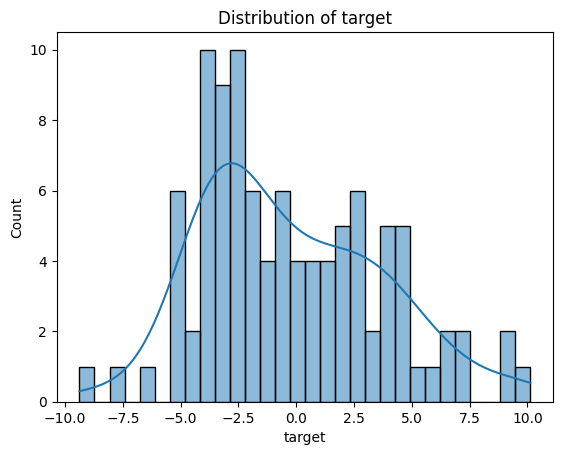

In [51]:
plt.figure()
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of target")
plt.show()

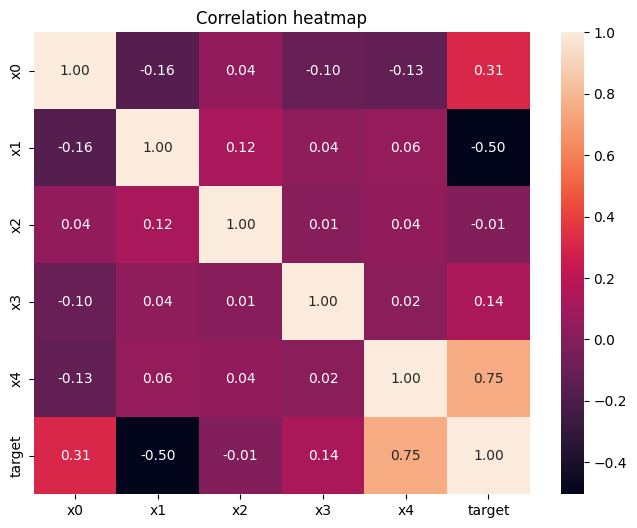

In [52]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

7

In [54]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [55]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [56]:
print("Class distribution:")
print(iris_df["target"].value_counts())

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


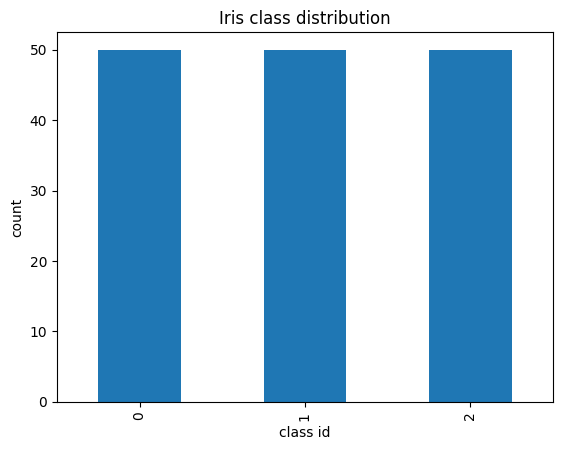

In [57]:
plt.figure()
iris_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Iris class distribution")
plt.xlabel("class id")
plt.ylabel("count")
plt.show()

In [58]:
# Train/test split
X_iris = iris_df.drop(columns=["target"])
y_iris = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

In [59]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

